# 2.3 — The 1:1 hedge and its three mismatches

> *"A hedge is a position in one thing taken in the hope that it will behave like another thing.
> The hope is where the risk lives."*

## The problem

The simplest hedge anybody proposes is *one for one*: long 50,000 MWh of something, sell 50,000 MWh of the
closest liquid future. It is intuitive, it is what the accounting team expects, and it is wrong in three
separate, measurable ways:

1. **Quantity mismatch** — lots are integers and hours differ by month (Chapter 1.1).
2. **Tenor mismatch** — the liquid contract is not the month you are exposed to (Chapter 1.4).
3. **Hub mismatch** — the liquid contract is not the hub you are exposed to (Chapter 1.5).

This chapter measures each residual in euros on the same 50,000 MWh position, so we know which mismatch
deserves engineering effort and which can be tolerated. The unifying idea is the **basis**.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.contracts import delivery_hours
from gashedge.market_data import simulate_curve_history, simulate_hub_history
from gashedge.hedging import hedged_pnl, hedge_effectiveness, min_variance_hedge_ratio, pnl_stats
from gashedge.plotting import plot_pnl_distributions
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.3")
log.info("Environment ready")

2026-09-13 16:47:02.658 | INFO    | ch2.3 | Environment ready


## 1. Basis: the one concept behind all three mismatches

Hold $Q$ MWh of exposure $S$, sell $hQ$ MWh of hedge $F$. Daily P&L:

$$
\Pi_t = Q\,\Delta S_t - hQ\,\Delta F_t = Q\left(\Delta S_t - h\,\Delta F_t\right)
\tag{2.6}
$$

Define the (generalised) **basis** $b_t = S_t - h F_t$. Then $\Pi_t = Q\,\Delta b_t$: **a hedged position
is a position in the basis.** Hedging does not remove risk; it *exchanges* outright risk for basis risk,
and the whole game is choosing $F$ and $h$ so that the basis is as quiet as possible. For a 1:1 hedge
$h=1$ and $b = S - F$, the plain price difference.

We will now build three bases and look at them.

In [2]:
Q = 50_000                                                  # MWh of exposure in each experiment
curve = simulate_curve_history(n_days=750, n_tenors=24)     # constant-maturity TTF tenors
hubs = simulate_hub_history(n_days=750, crisis=False)       # TTF / PEG / NBP front month
dC = curve.diff().dropna()
dH = hubs.diff().dropna()
log.info("Loaded %d days of curve history and %d days of hub history", len(dC), len(dH))

2026-09-13 16:47:02.666 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:02.671 | INFO    | gashedge.market_data | Simulated 750 days of hub history (crisis=False); TTF range 21.7-59.9


2026-09-13 16:47:02.672 | INFO    | ch2.3 | Loaded 749 days of curve history and 749 days of hub history


## 2. Mismatch 1 — quantity (lot rounding)

The December contract has 744 hours; 50,000 MWh is 67.2 lots. Sell 67 lots and 152 MWh stay unhedged.
The residual P&L is $152 \times \Delta P$. Small — but let us be honest and compute it rather than assume.

In [3]:
H = delivery_hours(2026, 12)
lots = round(Q / H)
residual_mwh = Q - lots * H
pnl_qty = hedged_pnl(dC.M1, dC.M1, Q, lots * H / Q)          # exact same instrument, just fewer MWh
s_qty = pnl_stats(pnl_qty.net, "quantity mismatch (152 MWh)")
log.info("Quantity mismatch: %d lots leaves %d MWh; residual daily P&L std %.0f EUR", lots, residual_mwh, s_qty["std"])
pd.Series({k: v for k, v in s_qty.items() if k != "name"}).round(0)

2026-09-13 16:47:02.676 | INFO    | ch2.3 | Quantity mismatch: 67 lots leaves 152 MWh; residual daily P&L std 198 EUR


mean       10.0
std       198.0
min      -816.0
q01      -559.0
q99       533.0
total    7430.0
dtype: float64

## 3. Mismatch 2 — tenor

Now the exposure is in a *different month* from the hedge. Three cases: M2 hedged with M1 (adjacent),
M6 with M1, and M12 with M1. All 1:1.

,std,unhedged_std,effectiveness,corr,min,q01
name,,,,,,
tenor mismatch M2 hedged with M1,29294.35,46077.04,0.60,0.92,-161600.0,-86962.0
tenor mismatch M6 hedged with M1,38091.41,35624.70,-0.14,0.88,-152100.0,-105154.0
tenor mismatch M12 hedged with M1,46749.68,31674.85,-1.18,0.74,-209250.0,-131542.0


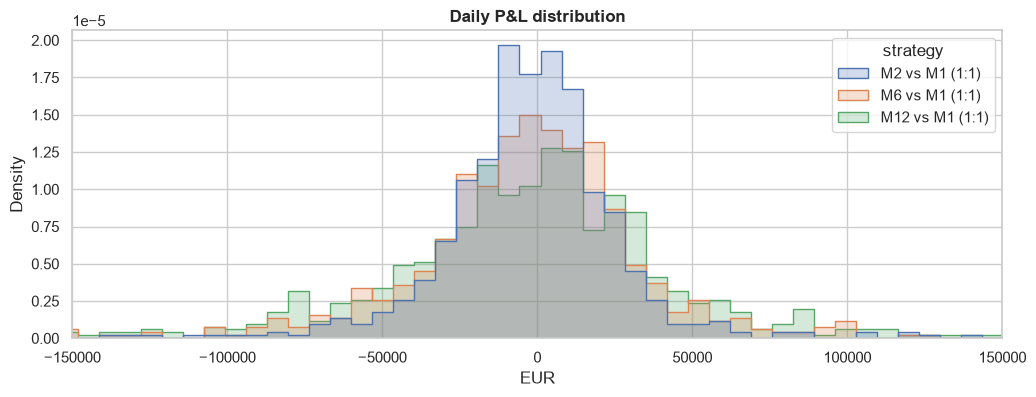

In [4]:
rows, pnls = [], {}
for t in (2, 6, 12):
    p = hedged_pnl(dC[f"M{t}"], dC.M1, Q, 1.0)
    pnls[f"M{t} vs M1 (1:1)"] = p.net
    rows.append({**pnl_stats(p.net, f"tenor mismatch M{t} hedged with M1"),
                 "unhedged_std": (Q * dC[f"M{t}"]).std(),
                 "effectiveness": hedge_effectiveness(dC[f"M{t}"], dC.M1, 1.0),
                 "corr": dC[f"M{t}"].corr(dC.M1)})
tenor_tbl = pd.DataFrame(rows).set_index("name")
fig, ax = plt.subplots(figsize=(12, 4))
plot_pnl_distributions(pnls, ax=ax); ax.set_xlim(-150_000, 150_000)
tenor_tbl[["std", "unhedged_std", "effectiveness", "corr", "min", "q01"]].round(2)

The adjacent-month hedge works well. The M12 hedge is a **disaster**: the hedged P&L is several times
*noisier* than the unhedged exposure (negative effectiveness), because we sold a volatile front-month
contract against a placid back-month one. This is the single most common mistake in first-generation
hedging engines — matching MWh, not risk. The fix (a ratio, Chapter 3.2) is easy; the diagnosis is what
matters here.

## 4. Mismatch 3 — hub

Exposure in PEG, hedge in TTF, same tenor, 1:1. This is the *basis* in the everyday sense of the word.

In [5]:
p_hub = hedged_pnl(dH.PEG, dH.TTF, Q, 1.0)
p_nbp = hedged_pnl(dH.NBP, dH.TTF, Q, 1.0)
hub_tbl = pd.DataFrame([
    {**pnl_stats(p_hub.net, "hub mismatch PEG hedged with TTF"), "unhedged_std": (Q * dH.PEG).std(),
     "effectiveness": hedge_effectiveness(dH.PEG, dH.TTF, 1.0), "corr": dH.PEG.corr(dH.TTF)},
    {**pnl_stats(p_nbp.net, "hub mismatch NBP hedged with TTF"), "unhedged_std": (Q * dH.NBP).std(),
     "effectiveness": hedge_effectiveness(dH.NBP, dH.TTF, 1.0), "corr": dH.NBP.corr(dH.TTF)},
]).set_index("name")
hub_tbl[["std", "unhedged_std", "effectiveness", "corr", "min", "q01"]].round(2)

,std,unhedged_std,effectiveness,corr,min,q01
name,,,,,,
hub mismatch PEG hedged with TTF,19653.54,72204.27,0.93,0.96,-106450.0,-55982.0
hub mismatch NBP hedged with TTF,45257.30,81723.96,0.69,0.83,-122650.0,-100100.0


## 5. The scoreboard

Same 50,000 MWh, same 1:1 rule, three mismatches. Which one should keep you awake?

,std,std_as_pct_of_unhedged_M1
name,,
quantity mismatch (152 MWh),198.1,0.3
tenor mismatch M2 hedged with M1,29294.4,45.0
tenor mismatch M6 hedged with M1,38091.4,58.5
tenor mismatch M12 hedged with M1,46749.7,71.7
hub mismatch PEG hedged with TTF,19653.5,30.2
hub mismatch NBP hedged with TTF,45257.3,69.5


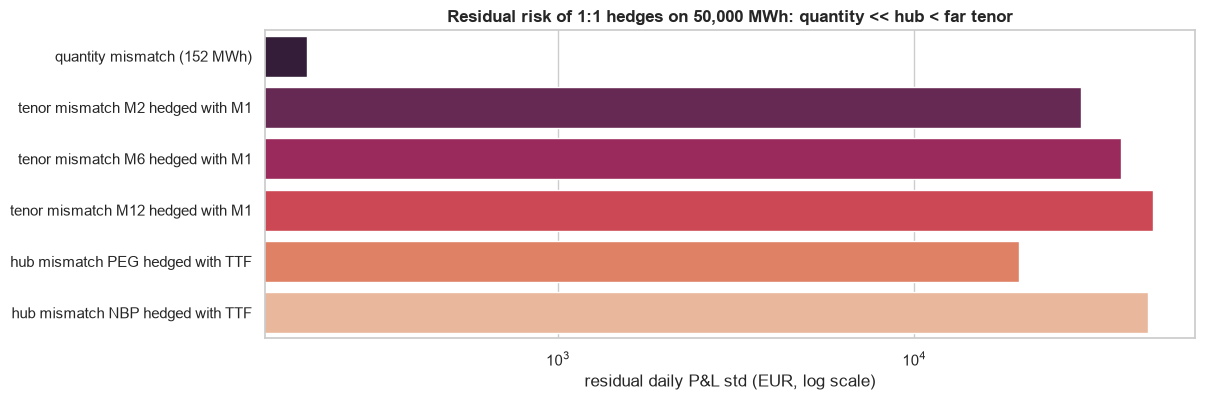

In [6]:
score = pd.concat([pd.DataFrame([s_qty]).set_index("name")[["std"]], tenor_tbl[["std"]], hub_tbl[["std"]]])
score["std_as_pct_of_unhedged_M1"] = 100 * score["std"] / (Q * dC.M1).std()
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=score.reset_index(), y="name", x="std", hue="name", legend=False, palette="rocket", ax=ax)
ax.set_xscale("log"); ax.set_xlabel("residual daily P&L std (EUR, log scale)"); ax.set_ylabel("")
ax.set_title("Residual risk of 1:1 hedges on 50,000 MWh: quantity << hub < far tenor")
score.round(1)

The ranking is robust to the seeds and to reasonable parameter changes, and it matches practitioner
experience:

* **Quantity** mismatch is noise. Log it, monitor the running total, ignore it otherwise.
* **Hub** mismatch is a manageable, mean-reverting residual in normal markets — and a regime risk in
  crises (Chapter 1.5). It needs a *limit* and a *stress*, not necessarily a hedge.
* **Tenor** mismatch, done 1:1, is *not a hedge at all* beyond a few months. It needs a **ratio**
  (Chapter 3.2), a **roll policy** (Chapter 2.4), or a **strip instrument** (Chapter 1.2).

## 6. A preview of the ratio fix

To show that the tenor problem is one of *size* rather than of *instrument*, compute the
minimum-variance ratio from Chapter 1.4 and re-run the M12 case.

In [7]:
h12 = min_variance_hedge_ratio(dC.M12, dC.M1)
p12 = hedged_pnl(dC.M12, dC.M1, Q, h12)
comp = pd.DataFrame([
    pnl_stats(Q * dC.M12, "M12 unhedged"),
    pnl_stats(hedged_pnl(dC.M12, dC.M1, Q, 1.0).net, "M12 hedged 1:1 with M1"),
    pnl_stats(p12.net, f"M12 hedged h*={h12:.2f} with M1"),
]).set_index("name")
log.info("Ratio h*=%.2f cuts M12 residual std from %.0f (1:1) to %.0f EUR/day; unhedged %.0f", h12,
         comp["std"].iloc[1], comp["std"].iloc[2], comp["std"].iloc[0])
comp[["std", "min", "q01", "q99"]].round(0)

2026-09-13 16:47:02.981 | INFO    | ch2.3 | Ratio h*=0.36 cuts M12 residual std from 46750 (1:1) to 21229 EUR/day; unhedged 31675


,std,min,q01,q99
name,,,,
M12 unhedged,31675.0,-189900.0,-90958.0,90588.0
M12 hedged 1:1 with M1,46750.0,-209250.0,-131542.0,130682.0
M12 hedged h*=0.36 with M1,21229.0,-146355.0,-56825.0,52576.0


## 7. Where this leaves us

A hedged book is a basis book. The three bases differ by orders of magnitude, and the tenor basis is the
one that can turn a hedge into a larger bet. Sizing fixes much of it — but even a correctly sized
front-month hedge of a back-month exposure has to be *maintained*: rolled every month, resized as
volatilities drift, and funded through margin.

**Pitfall that leads to the next chapter:** we evaluated static hedges on constant-maturity data. Real
contracts expire. A front-month hedge of a Dec-27 exposure will be rolled fourteen times, and each roll
crosses a spread and realises the curve's shape. That is *stack-and-roll* — and its most famous failure
lost $1.3 bn. Chapter 2.4.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Write the hedged P&L for a position long $Q$ of $S$ and short $hQ$ of $F$ as a position in a single synthetic asset. If $h = 1$, $\sigma_{\Delta S} = 1.1$, $\sigma_{\Delta F} = 1.2$ and $\rho = 0.6$, what is the standard deviation of that synthetic asset's daily change, and is the hedge helping?

<details><summary><i>Answer 1</i></summary>

$\Pi = Q\,\Delta b$ with $b = S - hF$ — the hedged book is long $Q$ of the basis. For $h=1$: $\sigma_b^2 = 1.21 + 1.44 - 2(0.6)(1.1)(1.2) = 2.65 - 1.584 = 1.066 \Rightarrow \sigma_b = \mathbf{1.03}$. Unhedged $\sigma_S = 1.10$, so the hedge removes only ~6 % of the standard deviation (about 12 % of the variance). Barely helping — and with the optimal $h^* = 0.6\times1.1/1.2 = 0.55$ the residual would be $\sigma_S\sqrt{1-\rho^2} = 1.1\times0.8 = 0.88$, a 36 % variance reduction. Size matters more than instrument choice here.

</details>

**Q2.** In the notebook the tenor mismatch M12-vs-M1 1:1 hedge shows *negative* effectiveness. Derive the condition on $\rho$ and $\sigma_F/\sigma_S$ under which a 1:1 hedge increases variance, and check it against the M12 numbers printed above.

<details><summary><i>Answer 2</i></summary>

Hedged variance $\sigma_S^2 + \sigma_F^2 - 2\rho\sigma_S\sigma_F > \sigma_S^2 \iff \sigma_F^2 > 2\rho\sigma_S\sigma_F \iff \boxed{\sigma_F/\sigma_S > 2\rho}$. For M12 vs M1 in the simulation $\sigma_F/\sigma_S$ is roughly 2–2.5 (front vol ≈ 56 % vs M12 ≈ 25 % annualised, Chapter 1.4) and $\rho \approx 0.75$, so $2\rho \approx 1.5 < 2.2$: the condition holds and the 1:1 hedge adds variance — as the table shows.

</details>

**Q3.** The quantity residual from lot rounding is tiny per position. Describe a realistic situation in which it becomes material, and a cheap engineering fix.

<details><summary><i>Answer 3</i></summary>

A book with hundreds of small positions each rounded *in the same direction* (e.g. always rounding down the hedge to avoid over-hedging) accumulates a systematic residual: 300 positions × ~370 MWh average residual = ~110,000 MWh — more than the whole example exposure. Fix: **net the residuals across the book before rounding** (round the *aggregate* per month, not each line), and carry the remaining sub-lot residual as an explicit position in the risk report so it is hedged when it crosses half a lot. Also use *banker's rounding* or alternate direction to avoid drift.

</details>

**Q4.** Effectiveness of the PEG-vs-TTF 1:1 hedge is high in the calm simulation. Give two reasons a desk might still choose to *hedge the basis explicitly* with a cleared PEG–TTF basis swap, and one reason it might not.

<details><summary><i>Answer 4</i></summary>

Reasons to hedge: (1) **Tail/regime risk** — the basis is quiet in calm markets but can move 10–30 EUR/MWh in a capacity crisis (Chapter 1.5); if the PEG book is large relative to the desk's limit the residual can breach it in a day. (2) **Capital / limit consumption** — warehoused basis risk consumes VaR and stress limits that the desk may prefer to spend on business it is paid for. Reason not to: the basis swap market is thin and wide (Chapter 1.3); paying a large spread every month to remove a small, mean-reverting residual has negative expected value — equation (2.4) with a large $c$ says hedge less.

</details>


---
◀ [Previous](02_instrument_menu.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](04_stack_and_roll.ipynb)